## Bayesian Causal Forest for HTE
**Model**: BCF for binary outcomes (probit link): model baseline μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $T \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from scipy.stats import norm
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from ISYE6420.Project.bcf_vis import build_ite_rd, plot_gates, build_clan_table, print_clan_table
rng = np.random.default_rng(123)
import xarray as xr

output_folder = "ISYE6420/Project/"

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "asthma"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420\\Project\\data\\{dx_name}_weighted_cohort.csv")
print(len(cohort))


65417


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
# Convert to binary indicator for outcome
y_data = (y > 0).astype(int)


In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 200,
    "beta_prior": 2,
    "alpha_prior": 0.95,
}

### 1. Prognostic Model $\mu(X, \hat{p})$

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 5.51%


In [6]:
X.columns

Index(['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline',
       'num_outpatient_event', 'num_er_event', 'hba1c_missing',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'nasal_polyps_flag',
       'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

### 2. $\tau$(X) Treatment Effect Model


In [7]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
#X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 50,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 3,     # more shrinkage towards homogenenous treatment effects
    "alpha_prior": 0.25,
}


## 3. Run BCF Model

In [ ]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)
    step = pm.DEMetropolis()

    trace_bcf = pm.sample(2000, tune=6000, step=step, chains=4)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)

Population sampling (4 chains)
DEMetropolis: [mu, tau]
Attempting to parallelize chains to all cores. You can turn this off with `pm.sample(cores=1)`.


Output()

Population parallelization failed. Falling back to sequential stepping of chains.


Output()

ValueError: setting an array element with a sequence.

In [ ]:
# Extract CATTs from joint model
mu_joint  = trace_bcf.posterior["mu"].mean(dim=["chain", "draw"]).values
tau_joint = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
tau_joint_sd = trace_bcf.posterior["tau"].std(dim=["chain", "draw"]).values

print(f"Joint CATT summary — mean: {tau_joint.mean():.4f}, sd: {tau_joint.std():.4f}")
print(f"ATT (treated only): {tau_joint[T == 1].mean():.4f}")

Joint CATT summary — mean: 0.0541, sd: 0.1379
ATT (treated only): 0.0508


In [ ]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_{dx_name}_binary_ex.nc")

'ISYE6420/Project/bcf_asthma_binary_ex.nc'

In [ ]:
zero_ppc = (ppc.posterior_predictive["y_likelihood"] == 0).mean(dim=["chain", "draw"])
print(zero_ppc.values.mean())  # compare to actual zero rate

0.9466022956570921


In [ ]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(f"Patients with R-hat > 1.01: {len(summary[summary['r_hat'] > 1.01])}")
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

Patients with R-hat > 1.01: 65417

Median ESS (bulk): 5
Patients with ESS < 100: 65417


## Load existing trace and compute CATE estimates

In [8]:
#Load trace from nc file
trace_bcf = az.from_netcdf(f"{output_folder}bcf_{dx_name}_binary_ex.nc")

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

# Now you can run PPC using the trace loaded from the .nc file
with bcf_joint:
    ppc = pm.sample_posterior_predictive(trace_bcf)

Sampling: [y_likelihood]


Output()

In [10]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(len(summary[summary["r_hat"] > 1.01]))
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

44037

Median ESS (bulk): 967
Patients with ESS < 100: 4165


In [10]:
from scipy.special import ndtr
mu_samples = trace_bcf.posterior['mu'].values.reshape(-1, X_mu.shape[0])
tau_samples = trace_bcf.posterior['tau'].values.reshape(-1, X_tau.shape[0])

# 1. Reconstruct latent probit scores
# Control state (counterfactual for treated, factual for control)
eta_0 = mu_samples + constant_intercept
# Treated state (factual for treated, counterfactual for control)
eta_1 = mu_samples + tau_samples + constant_intercept 

# 2. Map through Standard Normal CDF to get Absolute Risks (Probabilities)
risk_0 = ndtr(eta_0)
risk_1 = ndtr(eta_1)

# 3. Calculate Individual Treatment Effects (ITE) on Risk Difference and Risk Ratio scales
ite_rd = risk_1 - risk_0
ite_rr = risk_1 / risk_0
    
# 4. Filter for Treated Patients to isolate the CATT
# Assuming `treated_indices` is a boolean mask or list of indices where Z == 1
treated_indices = (T == 1)
rd_treated = ite_rd[:, treated_indices]
rr_treated = ite_rr[:, treated_indices]

# Calculate Posterior ATT (Mean and 95% HDI)
catt_rd_posterior = rd_treated.mean(axis=1)

print(f"ATT (Risk Difference) Mean: {catt_rd_posterior.mean():.4f}")
print(f"ATT (Risk Difference) 95% HDI: [{np.quantile(catt_rd_posterior, 0.025):.4f}, {np.quantile(catt_rd_posterior, 0.975):.4f}]")

MemoryError: Unable to allocate 3.90 GiB for an array with shape (8000, 65417) and data type float64

In [11]:
# --- ATT ---
tau = trace_bcf.posterior["tau"]
# Boolean index of treated patients
treated_mask = T.astype(bool)  # shape (66000,)

# Mean over treated patients within each (chain, draw)
# Result shape: (4, 2000)
att_draws = tau.values[:, :, treated_mask].mean(axis=-1)

# Wrap in xarray for ArviZ (needs chain/draw dims)
att_xr = xr.DataArray(
    att_draws,
    dims=["chain", "draw"]
)
rhat_att = az.rhat(xr.Dataset({"ATT": att_xr}))
ess_att  = az.ess(xr.Dataset({"ATT": att_xr}))
print(rhat_att, ess_att)

tau_mean = tau.values.reshape(-1, tau.shape[-1]).mean(axis=0)  # (66000,)
decile_labels = pd.qcut(tau_mean[treated_mask], q=10, labels=False)

n_chains, n_draws = tau.shape[:2]
n_deciles = 5
gates_draws = np.zeros((n_chains, n_draws, n_deciles))

for d in range(n_deciles):
    decile_idx = np.where(decile_labels == d)[0]
    gates_draws[:, :, d] = tau.values[:, :, treated_mask][:, :, decile_idx].mean(axis=-1)

gates_xr = xr.DataArray(
    gates_draws,
    dims=["chain", "draw", "decile"]
)
rhat_gates = az.rhat(xr.Dataset({"GATES": gates_xr}))
ess_gates  = az.ess(xr.Dataset({"GATES": gates_xr}))
print(rhat_gates)
print(ess_gates)

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    ATT      float64 8B 1.006 <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    ATT      float64 8B 2.911e+03
<xarray.Dataset> Size: 40B
Dimensions:  (decile: 5)
Dimensions without coordinates: decile
Data variables:
    GATES    (decile) float64 40B 1.029 1.03 1.02 1.015 1.009
<xarray.Dataset> Size: 40B
Dimensions:  (decile: 5)
Dimensions without coordinates: decile
Data variables:
    GATES    (decile) float64 40B 1.511e+03 1.871e+03 ... 2.556e+03 2.763e+03


In [12]:
print(rhat_gates["GATES"].values)

[1.02856727 1.03036184 1.02007649 1.01473711 1.00894513]


In [ ]:
ate_posterior = trace_bcf.posterior["tau"].mean(dim="tau_dim_0")

# 2. Check the R-hat of the aggregated metric
print("ATE R-hat:", az.rhat(ate_posterior).values)

MemoryError: Unable to allocate 3.90 GiB for an array with shape (4, 2000, 65417) and data type float64

In [23]:
# 1. Extract the posterior draws for tau (shape: chains, draws, patients)
tau_samples = trace_bcf.posterior["tau"].values

# 2. Compute the posterior mean for each patient to assign them to a decile
# (Using the mean over chains and draws to get the expected CATE per patient)
patient_expected_cate = tau_samples.mean(axis=(0, 1))

# 3. Assign patients to deciles (1 to 10)
decile_labels = np.digitize(
    patient_expected_cate, 
    np.percentile(patient_expected_cate, np.linspace(0, 100, 11))
)
# Adjust bounds so maximum value falls into decile 10
decile_labels = np.clip(decile_labels, 1, 10)

# 4. Calculate R-hat for each individual decile group
print("--- GATES Decile Convergence Verification ---")
for k in range(1, 11):
    group_mask = (decile_labels == k)
    
    # Average tau across only the patients in this specific decile
    # Resulting shape will be (chains, draws), representing the group's effect profile
    decile_posterior = trace_bcf.posterior["tau"].isel(tau_dim_0=group_mask).mean(dim="tau_dim_0")
    
    decile_rhat = az.rhat(decile_posterior)
    print(f"Decile {k} GATES R-hat: {decile_rhat.values}")

--- GATES Decile Convergence Verification ---
Decile 1 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.027>
Decile 2 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.027>
Decile 3 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.026>
Decile 4 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.023>
Decile 5 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.018>
Decile 6 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.015>
Decile 7 GATES R-hat: <bound method Mapping.values of <xarray.Dataset> Size: 8B
Dimensions:  ()


<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    tau      float64 8B 1.027

## Decision Tree Proxy for CATTs that are clinically interpretable

In [10]:
from sklearn.tree import DecisionTreeRegressor
# 1. Take the mean estimated treatment effect for each patient
catt_estimates = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
sorted_catt = np.sort(catt_estimates)
catt_rate_ratios = np.exp(catt_estimates)
y_proxy = catt_estimates

# Drop region columns if they exist, since they are not clinically interpretable
administrative_cols = [col for col in X.columns if 'region' in col.lower() or 'site' in col.lower()]
X_tau_clinical = X.drop(columns=administrative_cols)
feature_names_clinical = X_tau_clinical.columns

# 2. Fit a shallow Decision Tree to explain these effects using your covariates
# Max depth 4 keeps it clinically interpretable (16 subgroups max)
proxy_tree = DecisionTreeRegressor(max_depth=4)
proxy_tree.fit(X_tau_clinical, y_proxy)

# 3. Get the feature importance and visualize the rules
feature_importance = proxy_tree.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names_clinical,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)
feature_importance_df.head(10).reset_index(drop=True)

,feature,importance
0,age,0.518144
1,t2dm_flag,0.370387
2,gina_step,0.100103
3,obstructive_sleep_apnea_flag,0.011366
4,total_exac_count,0.000000
5,num_er_event,0.000000
6,hba1c_missing,0.000000
7,num_treatments_baseline,0.000000
8,num_outpatient_event,0.000000
9,ckd_flag,0.000000


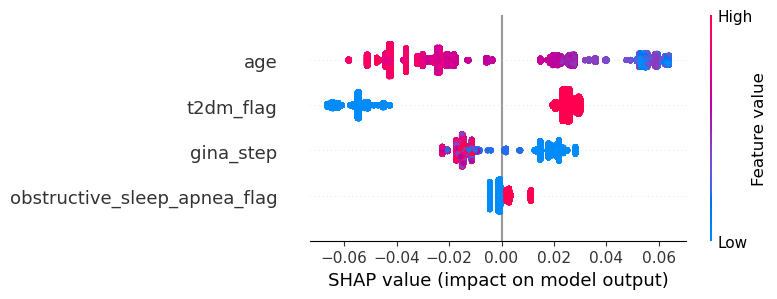

In [13]:
# SHAP values for the tree
import shap
explainer = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_tau_clinical)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_tau_clinical, feature_names=feature_names_clinical, max_display=4)


## GATES and CLANs

Building ITE-RD posterior arrays …
  ite_rd shape        : (8000, 65417)
  rd_treated shape    : (8000, 13547)
  mean(CATT)          : -0.00457

── A: GATES plot ──


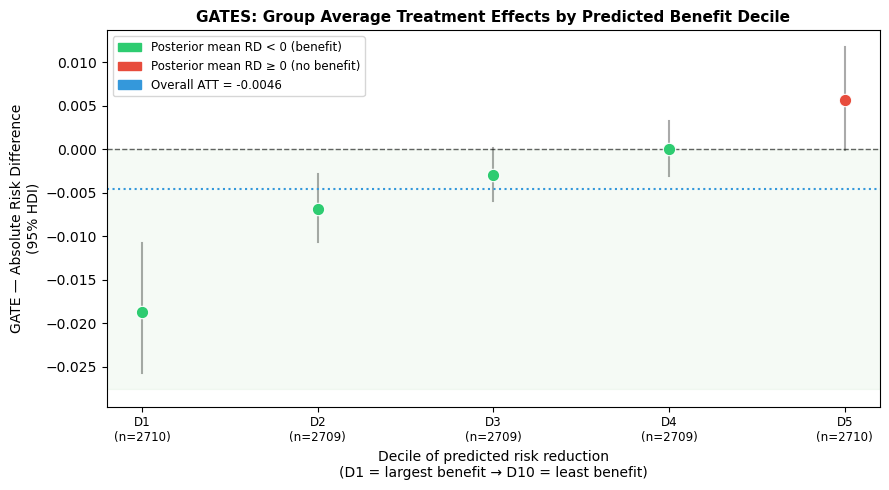

 decile    n     gate_mean        lo        hi  p_benefit
      1 2710 -1.870321e-02 -0.025749 -0.010733   1.000000
      2 2709 -6.889710e-03 -0.010652 -0.002819   0.999750
      3 2709 -2.950791e-03 -0.005960  0.000134   0.971500
      4 2709 -6.195137e-07 -0.003128  0.003193   0.509000
      5 2710  5.672980e-03 -0.000067  0.011692   0.026875


In [12]:
# ── Step 0: (Re)build ITE-RD posterior ───────────────────────────────
print("Building ITE-RD posterior arrays …")
ite_rd, rd_treated, mean_rd_treated, treated_mask = build_ite_rd(
    trace_bcf, X_mu, X_tau, T, constant_intercept)
print(f"  ite_rd shape        : {ite_rd.shape}")
print(f"  rd_treated shape    : {rd_treated.shape}")
print(f"  mean(CATT)          : {rd_treated.mean():.5f}")

# ── A: GATES ─────────────────────────────────────────────────────────
print("\n── A: GATES plot ──")
gates_df = plot_gates(
    rd_treated, mean_rd_treated,
    n_deciles=5,
    save_path="fig_gates_rd.png"
)
print(gates_df.to_string(index=False))


In [13]:
# ── B: CLAN ──────────────────────────────────────────────────────────
import importlib
import ISYE6420.Project.bcf_vis as bcf_vis
importlib.reload(bcf_vis)
print("\n── B: CLAN table ──")
clan_df = bcf_vis.build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.10,
    smd_threshold=0.10,
    ite_rd=ite_rd,
    
)
bcf_vis.print_clan_table(clan_df, top_pct=0.10)


── B: CLAN table ──


TypeError: build_clan_table() got an unexpected keyword argument 'ite_rd'

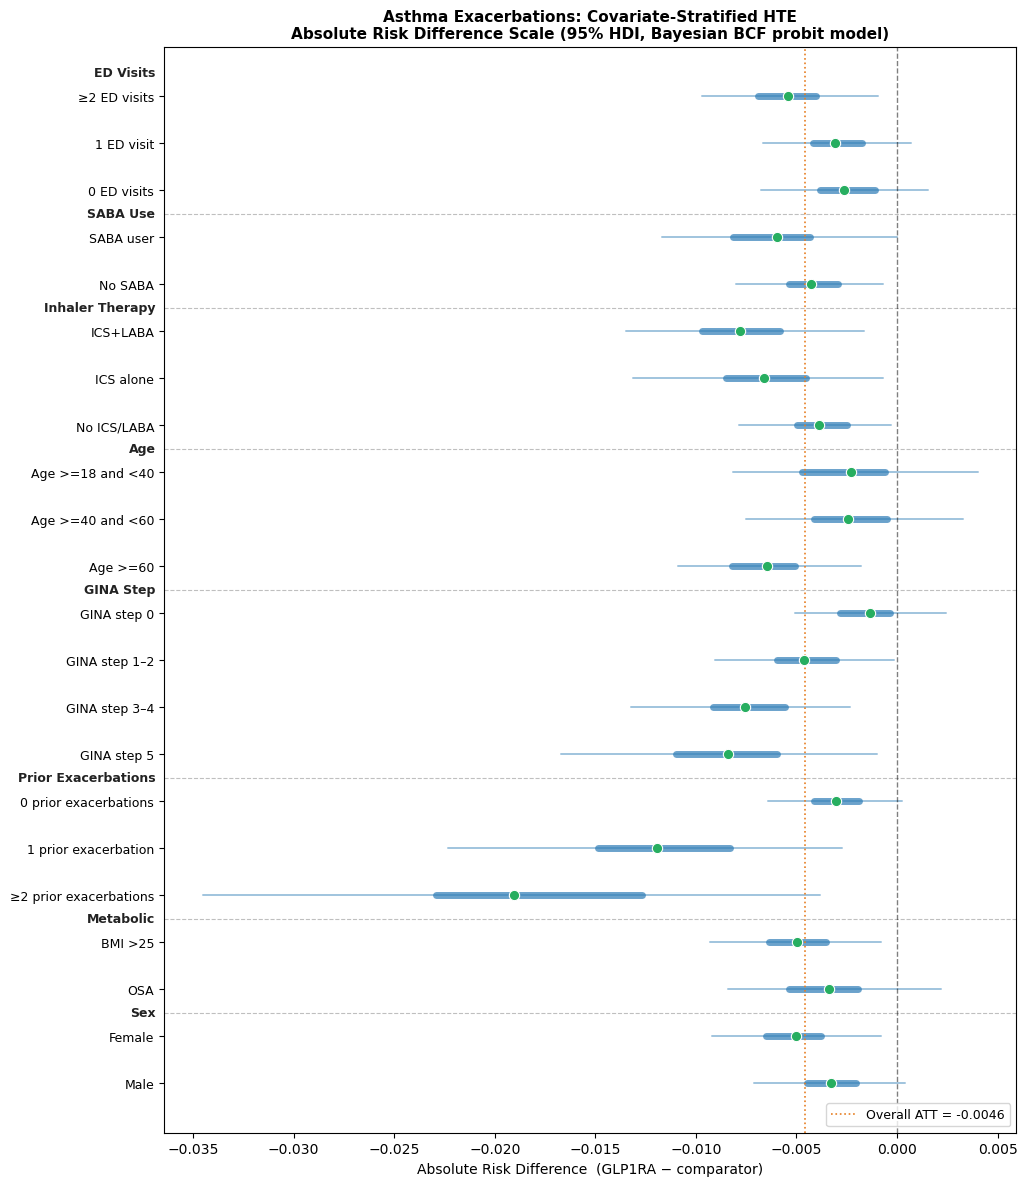

              group                  label     n      mean      lo95      hi95  p_benefit
          ED Visits           ≥2 ED visits  9038 -0.005446 -0.009717 -0.000944   0.992250
          ED Visits             1 ED visit  1851 -0.003081 -0.006651  0.000679   0.948250
          ED Visits            0 ED visits  2658 -0.002652 -0.006748  0.001541   0.897000
           SABA Use              SABA user  2524 -0.005951 -0.011678 -0.000016   0.975875
           SABA Use                No SABA 11023 -0.004259 -0.008002 -0.000678   0.987000
    Inhaler Therapy               ICS+LABA  2401 -0.007808 -0.013488 -0.001657   0.994000
    Inhaler Therapy              ICS alone   525 -0.006598 -0.013140 -0.000707   0.981875
    Inhaler Therapy            No ICS/LABA 11146 -0.003878 -0.007847 -0.000296   0.977000
                Age       Age >=18 and <40  1382 -0.002310 -0.008147  0.004009   0.773750
                Age       Age >=40 and <60  4906 -0.002449 -0.007486  0.003298   0.816250
          

In [23]:
# ══════════════════════════════════════════════════════════════════════════
# CELL C — HTE Forest Plot on the absolute Risk Difference scale
# Assumes: ite_rd, X, T, constant_intercept are in scope from Cell A
# ══════════════════════════════════════════════════════════════════════════

def rd_stratum(ite_rd, full_mask, T_arr, hdi_prob=0.95):
    """CATE among treated patients within full_mask."""
    mask = full_mask & T_arr.astype(bool)
    if mask.sum() < 20:
        return None
    draws      = ite_rd[:, mask].mean(axis=1)
    hdi_v      = az.hdi(draws, hdi_prob=hdi_prob)
    lo50, hi50 = az.hdi(draws, hdi_prob=0.50)
    return dict(mean=draws.mean(), lo95=hdi_v[0], hi95=hdi_v[1],
                lo50=lo50, hi50=hi50,
                p_benefit=float((draws < 0).mean()), n=int(mask.sum()))

Xd = X.reset_index(drop=True)

strata = [
    ("≥2 ED visits",          "ED Visits",          (Xd["num_er_event"] >= 2).values),
    ("1 ED visit",            "ED Visits",          (Xd["num_er_event"] == 1).values),
    ("0 ED visits",           "ED Visits",          (Xd["num_er_event"] == 0).values),
    ("SABA user",             "SABA Use",           (Xd["SABA_flag"] == 1).values),
    ("No SABA",               "SABA Use",           (Xd["SABA_flag"] == 0).values),
    ("ICS+LABA",              "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 1).values),
    ("ICS alone",             "Inhaler Therapy",    ((Xd["ICS_flag"]==1)).values),
    ("No ICS/LABA",           "Inhaler Therapy",    (Xd["ICS_LABA_flag"] == 0).values),
    ("Age >=18 and <40",       "Age",               ((Xd["age"] >= 18) & (Xd["age"] < 40)).values),
    ("Age >=40 and <60",       "Age",               ((Xd["age"] >= 40) & (Xd["age"] < 60)).values),
    ("Age >=60",               "Age",               (Xd["age"] >= 60).values),
    ("GINA step 0",           "GINA Step",          (Xd["gina_step"] == 0).values),
    ("GINA step 1–2",         "GINA Step",          ((Xd["gina_step"]>=1)&(Xd["gina_step"]<=2)).values),
    ("GINA step 3–4",         "GINA Step",          ((Xd["gina_step"]>=3)&(Xd["gina_step"]<=4)).values),
    ("GINA step 5",           "GINA Step",          (Xd["gina_step"] == 5).values),
    ("0 prior exacerbations", "Prior Exacerbations",(Xd["total_exac_count"] == 0).values),
    ("1 prior exacerbation",  "Prior Exacerbations",(Xd["total_exac_count"] == 1).values),
    ("≥2 prior exacerbations","Prior Exacerbations",(Xd["total_exac_count"] >= 2).values),
    ("BMI >25",               "Metabolic",          (Xd["bmi_above_25"] == 1).values),
    ("OSA",                   "Metabolic",          (Xd["obstructive_sleep_apnea_flag"]==1).values),
    ("Female",                "Sex",                (Xd["sex_Female"] == 1).values),
    ("Male",                  "Sex",                (Xd["sex_Female"] == 0).values),
]

rows = []
for label, group, mask in strata:
    r = rd_stratum(ite_rd, mask, T)
    if r:
        rows.append({"label": label, "group": group, **r})

forest_df = pd.DataFrame(rows)

# ── Draw ──────────────────────────────────────────────────────────────────
n_r    = len(forest_df)
colour = "#2c7bb6"
fig, ax = plt.subplots(figsize=(11, max(6, 0.55 * n_r + 2)))

y_pos          = np.arange(n_r)[::-1]
current_group  = None

for i, (_, row) in enumerate(forest_df.iterrows()):
    y = y_pos[i]
    if row["group"] != current_group:
        current_group = row["group"]
        # add line break and group label
        if i > 0:
            ax.axhline(y + 0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax.text(-0.01, y + 0.5, row["group"],
                transform=ax.get_yaxis_transform(),
                ha="right", va="center",
                fontsize=9, fontweight="bold", color="#222222")
        # add more space above and below group label

    ax.plot([row["lo95"], row["hi95"]], [y, y],
            color=colour, lw=1.4, alpha=0.45, solid_capstyle="round")
    ax.plot([row["lo50"], row["hi50"]], [y, y],
            color=colour, lw=5,   alpha=0.70, solid_capstyle="round")
    dot_c = "#27ae60" if row["mean"] < 0 else "#e74c3c"
    ax.scatter(row["mean"], y, s=55, color=dot_c, zorder=5,
               edgecolors="white", linewidths=0.8)
    # ax.text(forest_df["hi95"].max() + 0.001, y,
    #         f"  {row['mean']:+.4f} [{row['lo95']:+.4f}, {row['hi95']:+.4f}]  "
    #         f"P(benefit)={row['p_benefit']:.2f}  n={row['n']}",
    #         va="center", fontsize=7.5, color="gray")

att_mean = ite_rd[:, T.astype(bool)].mean()
ax.axvline(0,        color="black",   lw=1,   ls="--", alpha=0.5)
ax.axvline(att_mean, color="#e67e22", lw=1.2, ls=":",
           label=f"Overall ATT = {att_mean:.4f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"].tolist(), fontsize=9)
ax.set_xlabel(
    "Absolute Risk Difference  (GLP1RA − comparator)",
    fontsize=10)
ax.set_title(
    "Asthma Exacerbations: Covariate-Stratified HTE\n"
    "Absolute Risk Difference Scale (95% HDI, Bayesian BCF probit model)",
    fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
#fig.tight_layout()
plt.show()
print(forest_df[["group","label","n","mean","lo95","hi95","p_benefit"]].to_string(index=False))